In [14]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [2]:
ivt_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_all_context_dwell-IVT_ON0105_allmotif_pileup/pileup.pkl"
ivt_df = pd.read_pickle(ivt_df)

In [15]:
cell_df = ("/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_dwell_all_npz-ON0090_allmotif_pileup/pileup.pkl")
cell_df = pd.read_pickle(cell_df)

In [4]:
print(cell_df)

                label_id      pm6a  count_pm6a       dom  count_dom  mean_pred
0         NM_000016:1000  0.000661       257.0  0.000000        258   0.001252
1         NM_000016:1008  0.000804       253.0  0.000000        255   0.001761
2         NM_000016:1009  0.002531       257.0  0.000000        258   0.002951
3         NM_000016:1010  0.003011       253.0  0.011628        258   0.013154
4         NM_000016:1014  0.003508       247.0  0.003968        252   0.008094
...                  ...       ...         ...       ...        ...        ...
30866310   NR_184306:979  0.022609        14.0  0.000000         14   0.022208
30866311    NR_184306:98  0.026973        31.0  0.052632         38   0.076848
30866312   NR_184306:984  0.000690        17.0  0.000000         17   0.000689
30866313   NR_184306:986  0.000763        17.0  0.000000         17   0.000762
30866314   NR_184306:997  0.003089        14.0  0.062500         16   0.059454

[30866315 rows x 6 columns]


In [20]:
ivt_df = ivt_df[ivt_df["count_pm6a"] >= 20]
cell_df = cell_df[cell_df["count_pm6a"] >= 20]

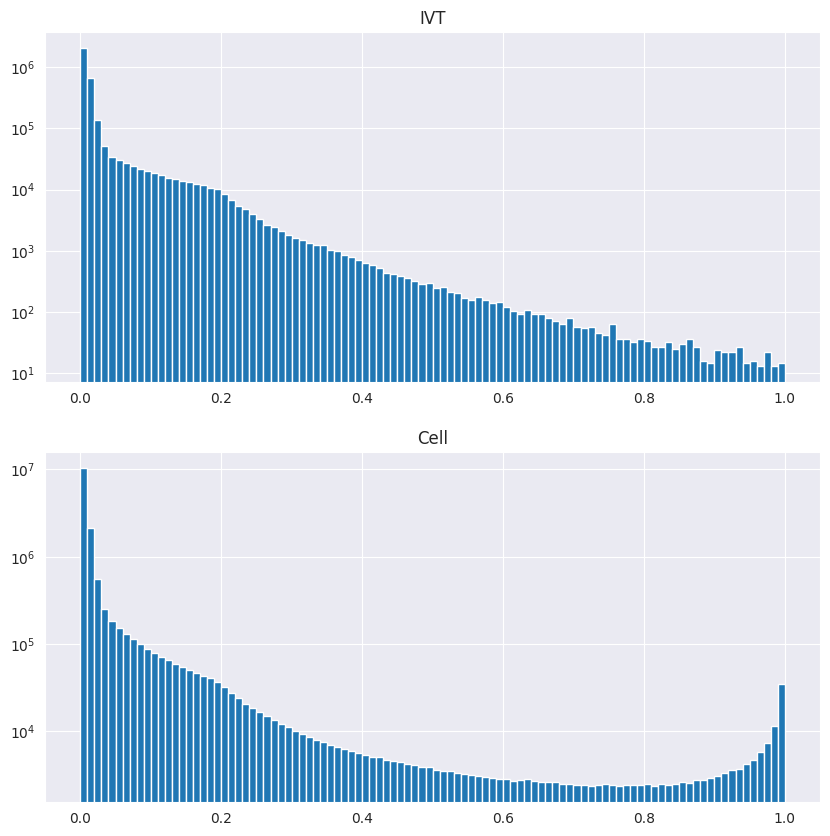

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10)) 
## Plot Histogram 
axes[0].set_yscale("log")
axes[1].set_yscale("log")
axes[0].set_title("IVT")
axes[1].set_title("Cell")
axes[0].hist(ivt_df["pm6a"], bins=100, range = (0, 1))
axes[1].hist(cell_df["pm6a"], bins=100, range = (0, 1))
plt.show()

In [47]:
ivt_hist, ivt_edges = np.histogram(ivt_df["pm6a"], bins=100, range = (0, 1))
cell_hist, cell_edges = np.histogram(cell_df["pm6a"], bins=100, range = (0, 1))

ivt_hist = np.log10(ivt_hist / np.sum(ivt_hist))
cell_hist = np.log10(cell_hist / np.sum(cell_hist))

diff_hist = cell_hist - ivt_hist
assert np.all(ivt_edges == cell_edges)



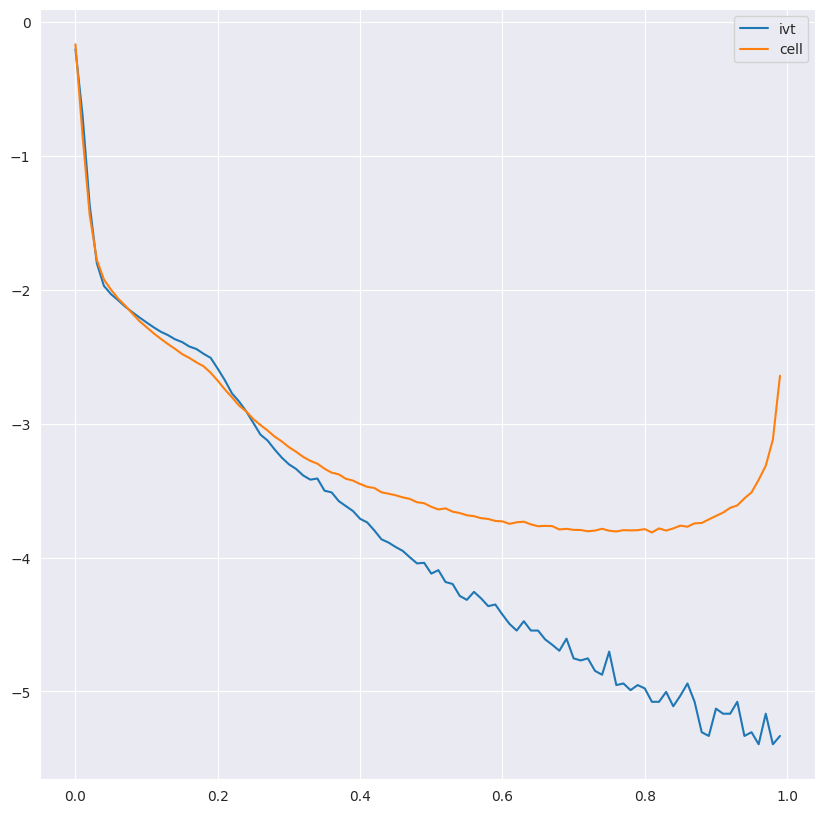

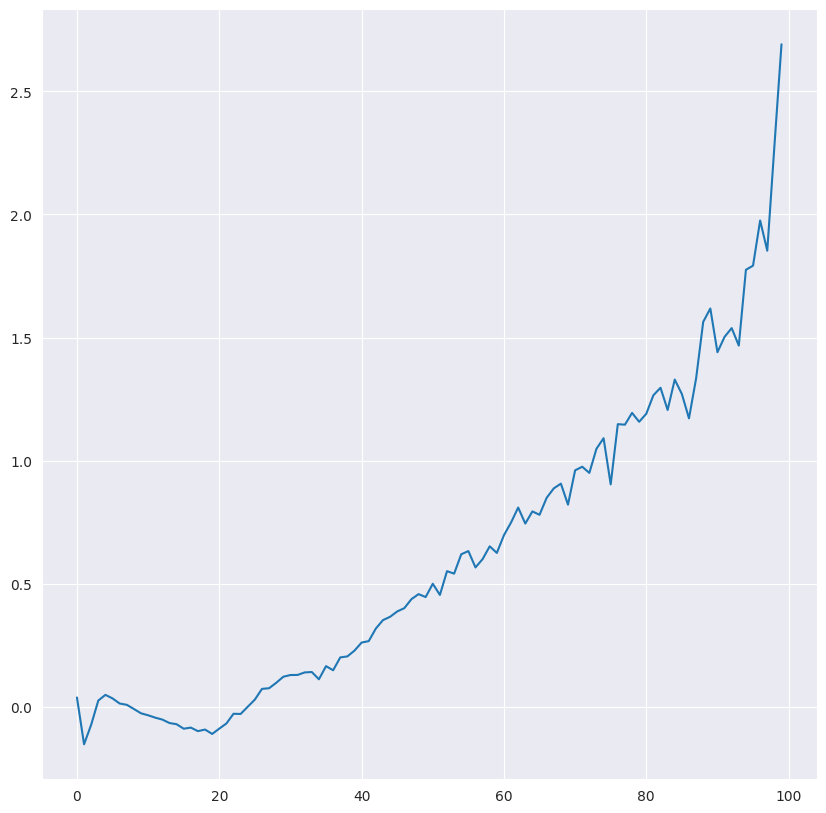

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(ivt_edges[:-1], ivt_hist, label="ivt")
ax.plot(cell_edges[:-1], cell_hist, label="cell")
ax.legend()
plt.show()
plt.close()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(diff_hist, label="diff")
plt.show()
plt.close()

In [5]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)

In [6]:
label_df_filtered = label_df.copy()
label_df_filtered = label_df_filtered[(label_df_filtered["dom_label"] > 0) | (label_df_filtered["label"] == 0)]
label_df_filtered = label_df_filtered[label_df_filtered["label"] >= 0]
print(label_df_filtered["label"].value_counts())

label
0    18399879
1      100118
Name: count, dtype: int64


In [21]:
cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")

In [18]:
print(cell_label_df)

                label_id      pm6a  count_pm6a       dom  count_dom  \
0         NM_000016:1000  0.000661       257.0  0.000000        258   
1         NM_000016:1008  0.000804       253.0  0.000000        255   
2         NM_000016:1009  0.002531       257.0  0.000000        258   
3         NM_000016:1010  0.003011       253.0  0.011628        258   
4         NM_000016:1014  0.003508       247.0  0.003968        252   
...                  ...       ...         ...       ...        ...   
18462560  NR_184210:2602  0.009456         5.0  0.000000          5   
18462561  NR_184210:2604  0.010849         5.0  0.000000          6   
18462562  NR_184210:2605  0.017382         6.0  0.000000          7   
18462563  NR_184210:2606  0.019895         6.0  0.142857          7   
18462564  NR_184210:2616  0.005822         3.0  0.000000          3   

          mean_pred  depth  label  dom_label   5mer  drach  
0          0.001252    268      0        0.0  AAACT   True  
1          0.001761    26

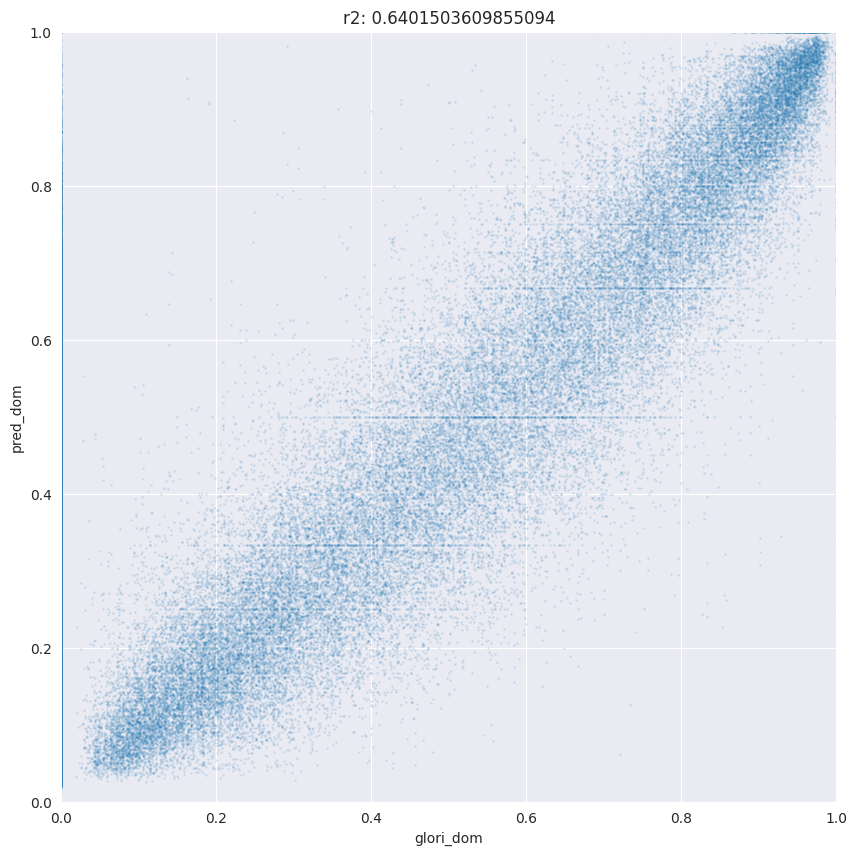

In [51]:
threshold = 0.2
selected_df = cell_label_df[cell_label_df["pm6a"] > threshold]

# selected_df = cell_label_df

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

In [9]:
dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl")

In [10]:
dorado_df = dorado_df[dorado_df["dorado_count"] >= 20]
print(dorado_df)

               label_id  pred_dorado  dorado_count
413         NM_000016:0       0.5250            40
414         NM_000016:2       0.0164            61
415         NM_000016:5       0.0822            73
417        NM_000016:21       0.0250           160
418        NM_000016:24       0.0710           155
...                 ...          ...           ...
59475965  NR_184306:326       0.1795            39
59475966  NR_184306:330       0.0488            41
59475967  NR_184306:331       0.0000            40
59475968  NR_184306:333       0.0000            41
59475969  NR_184306:334       0.0000            24

[15457254 rows x 3 columns]


In [11]:
dorado_label_df = dorado_df.merge(label_df_filtered, on="label_id", how="inner")
print(dorado_label_df)

                label_id  pred_dorado  dorado_count  depth  label  dom_label  \
0           NM_000016:21       0.0250           160    168      0        0.0   
1           NM_000016:24       0.0710           155    182      0        0.0   
2           NM_000016:29       0.0460           174    199      0        0.0   
3           NM_000016:30       0.0266           188    200      0        0.0   
4           NM_000016:38       0.0054           185    201      0        0.0   
...                  ...          ...           ...    ...    ...        ...   
10438531  NR_182669:3964       0.0000            47     55      0        0.0   
10438532  NR_182669:3965       0.0000            53     55      0        0.0   
10438533  NR_182669:3966       0.1458            48     55      0        0.0   
10438534  NR_182669:3968       0.0000            50     55      0        0.0   
10438535  NR_182669:3969       0.0204            49     55      0        0.0   

           5mer  drach  
0         GGAG

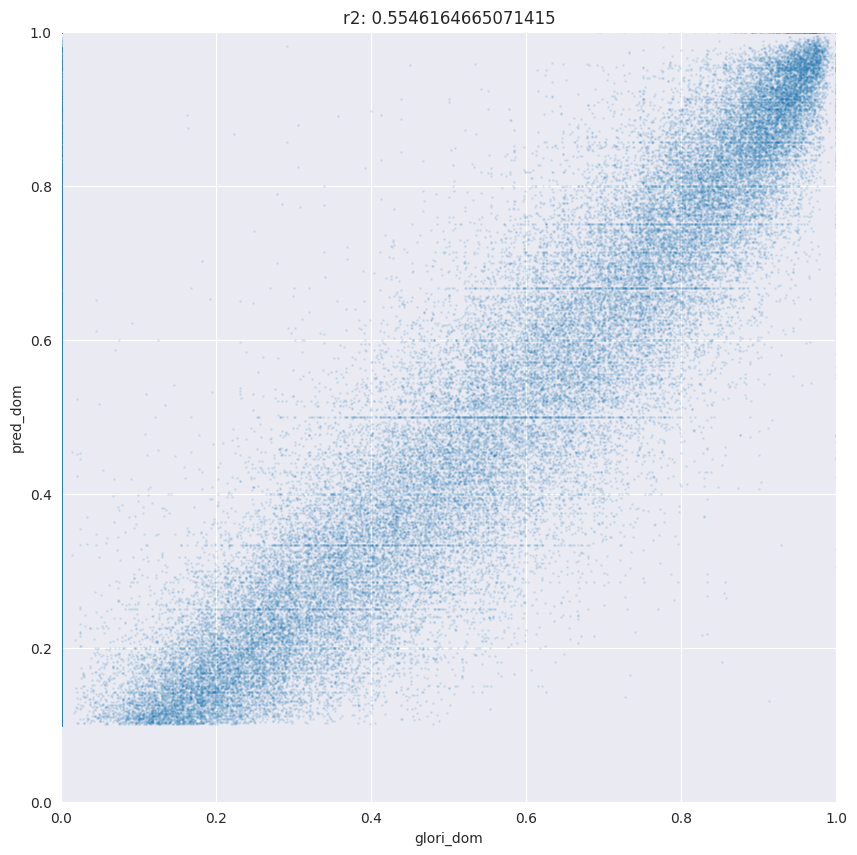

In [12]:
selected_df = dorado_label_df
selected_df = selected_df[selected_df["pred_dorado"] > 0.1]
# selected_df = selected_df[~selected_df["drach"]]


from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["pred_dorado"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["pred_dorado"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)


plt.show()
plt.close()

In [ ]:
threshold = 0.2
selected_df = cell_label_df[cell_label_df["pm6a"] > threshold]

glori_neg_df = selected_df[selected_df["dom_label"] == 0]
glori_pos_df = selected_df[selected_df["dom_label"] > 0]
print(glori_neg_df)
print(glori_pos_df)



In [ ]:
## 5mer counts

table_5mer_neg = glori_neg_df["5mer"].value_counts().sort_values(ascending=False)
table_5mer_pos = glori_pos_df["5mer"].value_counts().sort_values(ascending=False)

print(table_5mer_neg[:10])
print(table_5mer_pos[:10])


In [ ]:
## depth histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.histplot(glori_neg_df["depth"], bins=100, ax=ax, color="red", label="GLORI=0", fill=False, stat="density", element="step")
sns.histplot(glori_pos_df["depth"], bins=100, ax=ax, color="yellow", label="GLORI>0", fill=False, stat="density", element="step")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()


In [ ]:

def get_drach_distance(motif):
    distance = 0
    if motif[0] == "C":
        distance += 1
    if motif[1] in ["C", "T"]:
        distance += 1
    if motif[3] != "C":
        distance += 1
    if motif[4] == "G":
        distance += 1
    return distance



In [ ]:
glori_neg_df["drach_distance"] = glori_neg_df["5mer"].apply(get_drach_distance)
glori_pos_df["drach_distance"] = glori_pos_df["5mer"].apply(get_drach_distance)

## drach distance histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.histplot(glori_neg_df["drach_distance"], bins=4, ax=ax, color="red", label="GLORI=0", fill=False, stat="density", element="step", binrange=(0, 4))
sns.histplot(glori_pos_df["drach_distance"], bins=4, ax=ax, color="yellow", label="GLORI>0", fill=False, stat="density", element="step", binrange=(0, 4))

ax.legend()

In [ ]:
## Violin plot: x = drach distance, y = pm6a, data = glori_neg_df
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.violinplot(x="drach_distance", y="pm6a", data=glori_neg_df, ax=ax, color="red")


In [ ]:
## Violin plot: x = drach distance, y = pm6a, data = glori_neg_df
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.violinplot(x="drach_distance", y="dom", data=glori_neg_df, ax=ax, color="red")


In [ ]:
## Violin plot: x = drach distance, y = pm6a, data = glori_neg_df
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.violinplot(x="drach_distance", y="pm6a", data=glori_pos_df, ax=ax, color="red")
## Violin plot: x = drach distance, y = pm6a, data = glori_neg_df
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.violinplot(x="drach_distance", y="dom", data=glori_pos_df, ax=ax, color="red")


In [ ]:

selected_df = dorado_label_df[dorado_label_df["pred_dorado"] > 0.0]
glori_neg_df_dorado = selected_df[selected_df["dom_label"] == 0]
glori_pos_df_dorado = selected_df[selected_df["dom_label"] > 0]

print(glori_neg_df_dorado)
print(glori_pos_df_dorado)



In [ ]:

glori_neg_df_dorado["drach_distance"] = glori_neg_df_dorado["5mer"].apply(get_drach_distance)
glori_pos_df_dorado["drach_distance"] = glori_pos_df_dorado["5mer"].apply(get_drach_distance)

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.violinplot(x="drach_distance", y="pred_dorado", data=glori_neg_df_dorado, ax=ax, color="red")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.violinplot(x="drach_distance", y="pred_dorado", data=glori_pos_df_dorado, ax=ax, color="red")



In [ ]:
print(glori_neg_df_dorado)

In [ ]:
print(glori_neg_df_dorado["pred_dorado"].describe())

In [ ]:
print(dorado_label_df)
print(cell_label_df)

In [ ]:
label_df_filtered = label_df.copy()
label_df_filtered[(label_df_filtered["dom_label"] == 0.0) & (label_df_filtered["label"] == 1)]["label"] = -1
label_df_filtered = label_df_filtered[label_df_filtered["label"] >= 0]

In [ ]:
print(dorado_label_df[dorado_label_df["pred_dorado"] > 0.0])

In [ ]:
print(np.sum(dorado_label_df["pred_dorado"] > 0.0))
print(np.sum(cell_label_df["pm6a"] > 0.2))

In [ ]:
print(len(dorado_label_df))
print(np.sum(dorado_label_df["pred_dorado"] > 0.2))
print(np.sum((dorado_label_df["pred_dorado"] > 0.2) & (dorado_label_df["dom_label"] == 0)))
print(np.sum((dorado_label_df["pred_dorado"] > 0.2) & (dorado_label_df["dom_label"] > 0)))

In [ ]:
print(len(cell_label_df))
print(np.sum( cell_label_df["pm6a"] > 0.5))
print(np.sum((cell_label_df["pm6a"] > 0.5) & (cell_label_df["dom_label"] == 0)))
print(np.sum((cell_label_df["pm6a"] > 0.5) & (cell_label_df["dom_label"] > 0)))

In [ ]:
called_pos_df = cell_label_df

In [ ]:
print(called_pos_df)

In [ ]:
fp_df = cell_label_df[cell_label_df["dom_label"] == 0]
tp_df = cell_label_df[cell_label_df["dom_label"] > 0]


fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(fp_df["dom"], fp_df["pm6a"], alpha=0.1, s = 1, color="red", label="fp")
ax.scatter(tp_df["dom"], tp_df["pm6a"], alpha=0.1, s = 1, color="green", label="tp")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()
plt.close()

In [ ]:
threshold = 0.2
selected_df = cell_label_df[cell_label_df["pm6a"] > threshold]

min_dom = selected_df["dom"].min()
print(min_dom)

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

In [ ]:
fp_df = cell_label_df[cell_label_df["dom_label"] == 0]
tp_df = cell_label_df[cell_label_df["dom_label"] > 0]


fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(fp_df["dom"], fp_df["pm6a"], alpha=0.1, s = 1, color="red", label="fp")
ax.scatter(tp_df["dom"], tp_df["pm6a"], alpha=0.1, s = 1, color="green", label="tp")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()

In [ ]:
plt.show()

In [ ]:
print(cell_label_df)

cell_label_df["threshold"] = np.log10(cell_label_df["dom"] + 0.15) + 0.9
selected_df = cell_label_df[cell_label_df["pm6a"] > cell_label_df["threshold"]]

print(selected_df)

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

In [ ]:
print(cell_label_df)

cell_label_df["threshold"] = 0.8 * cell_label_df["dom"] + 0.15
selected_df = cell_label_df[cell_label_df["pm6a"] > cell_label_df["threshold"]]

print(selected_df)

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

In [ ]:
fp_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-v3B-20240726-105403-22-379000-token_normalise_dwell_all_npz-ON0090_allmotif_pileup/fp.pkl")


In [ ]:
tp_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-v3B-20240726-105403-22-379000-token_normalise_dwell_all_npz-ON0090_allmotif_pileup/tp.pkl")


In [ ]:
print(fp_df)
print(tp_df)

In [ ]:
print(np.sort(pred_dict[list(pred_dict.keys())[0]]))
print(len(pred_dict))

In [ ]:
def aggregate_pm6a(pm6a_arr):
    pm6a_arr = pm6a_arr[(pm6a_arr >= 0.98) | (pm6a_arr <= 0.1)]
    pm6a_arr = 1 - 10**(np.sum(np.log10(1 - np.clip(pm6a_arr, 0, 1-1e-20))) / len(pm6a_arr))
    return pm6a_arr

def aggregate_dom(dom_arr):
    dom_arr = dom_arr[(dom_arr >= 0.6) | (dom_arr <= 0.2)] > 0.5
    dom_arr = np.mean(dom_arr)
    return dom_arr


                label_id      pm6a  count_pm6a       dom  count_dom  \
0         NM_000016:1000  0.000661       257.0  0.000000        258   
1         NM_000016:1008  0.000804       253.0  0.000000        255   
2         NM_000016:1009  0.002531       257.0  0.000000        258   
3         NM_000016:1010  0.003011       253.0  0.011628        258   
4         NM_000016:1014  0.003508       247.0  0.003968        252   
...                  ...       ...         ...       ...        ...   
10257993  NR_182669:3964  0.006612        49.0  0.000000         52   
10257994  NR_182669:3965  0.005538        51.0  0.000000         51   
10257995  NR_182669:3966  0.006250        43.0  0.021739         46   
10257996  NR_182669:3968  0.100220        44.0  0.063830         47   
10257997  NR_182669:3969  0.005694        38.0  0.024390         41   

          mean_pred  depth  label  dom_label   5mer  drach  threshold  
0          0.001252    268      0        0.0  AAACT   True   0.100000  
1  

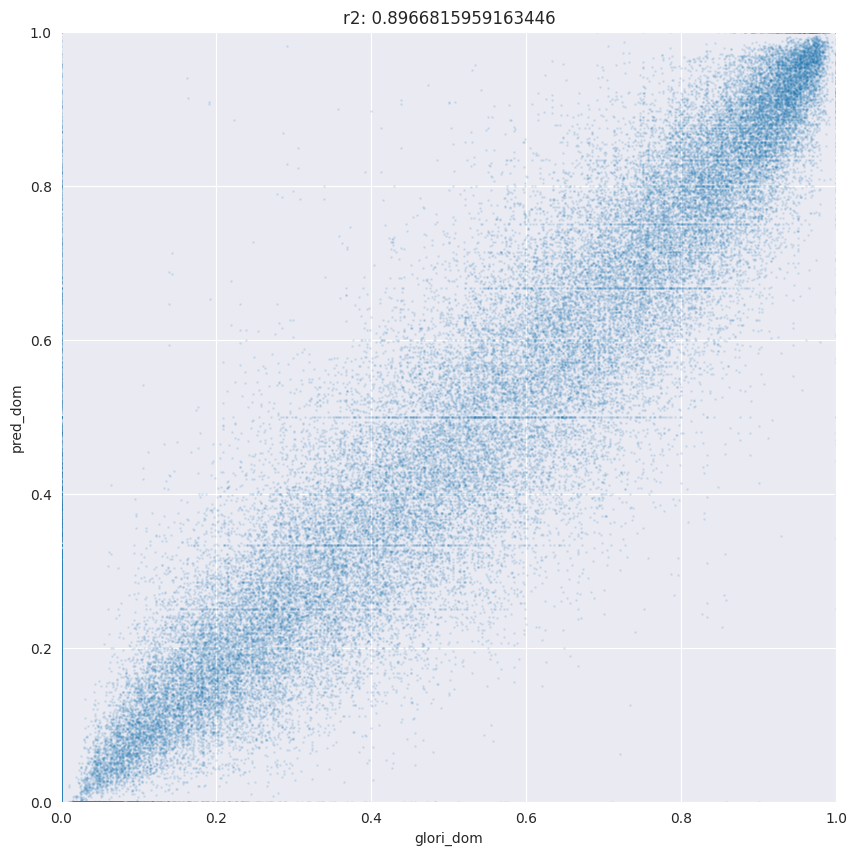

In [32]:
print(cell_label_df)

cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (cell_label_df["dom"])))
selected_df = cell_label_df[(cell_label_df["pm6a"] > cell_label_df["threshold"])] 
print(selected_df)

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

                label_id      pm6a  count_pm6a       dom  count_dom  \
0         NM_000016:1000  0.000661       257.0  0.000000        258   
1         NM_000016:1008  0.000804       253.0  0.000000        255   
2         NM_000016:1009  0.002531       257.0  0.000000        258   
3         NM_000016:1010  0.003011       253.0  0.011628        258   
4         NM_000016:1014  0.003508       247.0  0.003968        252   
...                  ...       ...         ...       ...        ...   
10257993  NR_182669:3964  0.006612        49.0  0.000000         52   
10257994  NR_182669:3965  0.005538        51.0  0.000000         51   
10257995  NR_182669:3966  0.006250        43.0  0.021739         46   
10257996  NR_182669:3968  0.100220        44.0  0.063830         47   
10257997  NR_182669:3969  0.005694        38.0  0.024390         41   

          mean_pred  depth  label  dom_label   5mer  drach  threshold  
0          0.001252    268      0        0.0  AAACT   True   0.100000  
1  

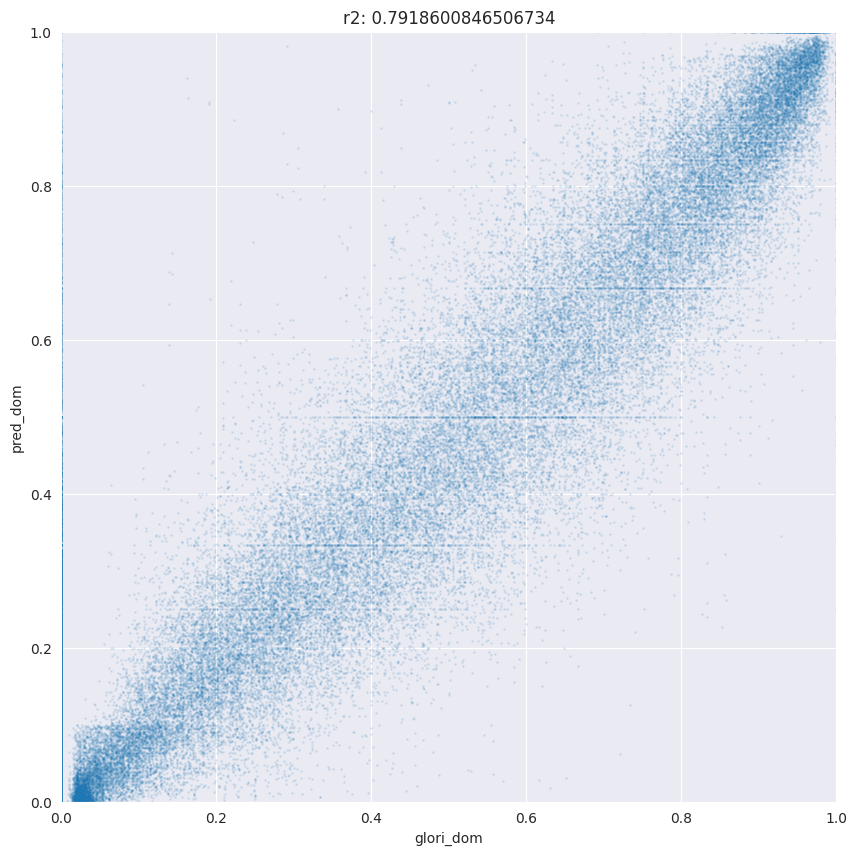

In [31]:
print(cell_label_df)

cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (cell_label_df["dom"])))
selected_df = cell_label_df[((cell_label_df["pm6a"] > cell_label_df["threshold"]) | (cell_label_df["dom"] < 0.1)) & (cell_label_df["dom"] > 0.0)]
print(selected_df)

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

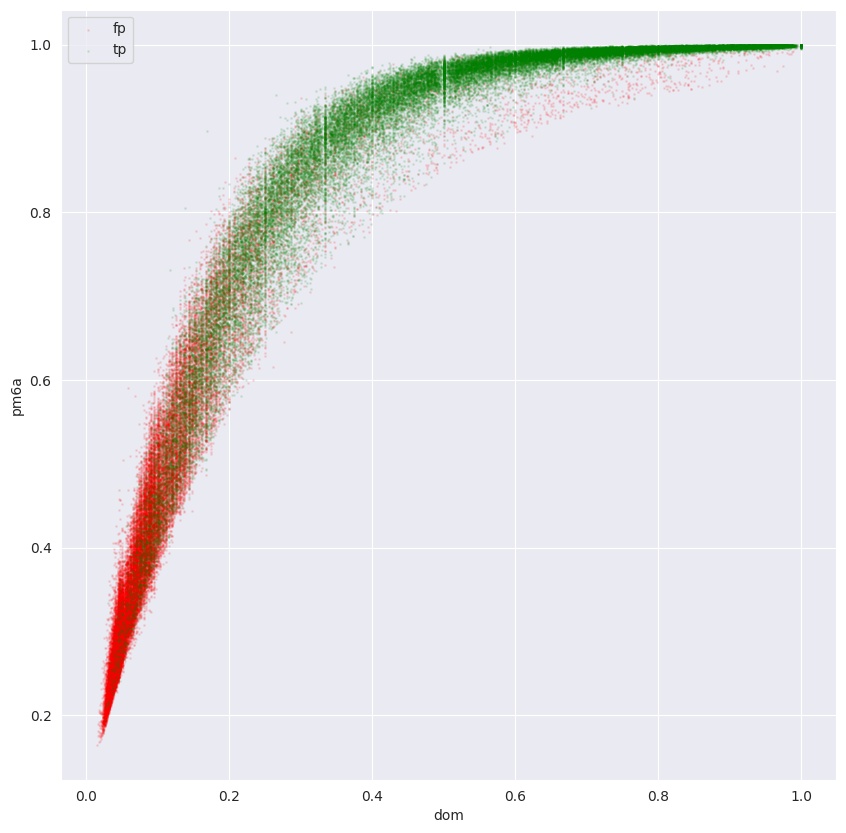

In [70]:
fp_df = selected_df[selected_df["dom_label"] == 0]
tp_df = selected_df[selected_df["dom_label"] > 0]


fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(fp_df["dom"], fp_df["pm6a"], alpha=0.1, s = 1, color="red", label="fp")
ax.scatter(tp_df["dom"], tp_df["pm6a"], alpha=0.1, s = 1, color="green", label="tp")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()

In [84]:
from sklearn.metrics import precision_recall_curve, auc


cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["mean_pred"])) * (0.02 ** (cell_label_df["mean_pred"])))
selected_df = cell_label_df[cell_label_df["pm6a"] > cell_label_df["threshold"]]

print(cell_label_df)
print(selected_df)

                label_id      pm6a  count_pm6a       dom  count_dom  \
0         NM_000016:1000  0.000661       257.0  0.000000        258   
1         NM_000016:1008  0.000804       253.0  0.000000        255   
2         NM_000016:1009  0.002531       257.0  0.000000        258   
3         NM_000016:1010  0.003011       253.0  0.011628        258   
4         NM_000016:1014  0.003508       247.0  0.003968        252   
...                  ...       ...         ...       ...        ...   
10257993  NR_182669:3964  0.006612        49.0  0.000000         52   
10257994  NR_182669:3965  0.005538        51.0  0.000000         51   
10257995  NR_182669:3966  0.006250        43.0  0.021739         46   
10257996  NR_182669:3968  0.100220        44.0  0.063830         47   
10257997  NR_182669:3969  0.005694        38.0  0.024390         41   

          mean_pred  depth  label  dom_label   5mer  drach  threshold  
0          0.001252    268      0        0.0  AAACT   True   0.104279  
1  

In [85]:
original_df_pr = cell_label_df[cell_label_df["label"] >= 0][["label_id", "pm6a"]]
selected_df_pr = selected_df[selected_df["label"] >= 0][["label_id", "pm6a"]]
dorado_df_pr = dorado_label_df[dorado_label_df["label"] >= 0][["label_id", "pred_dorado"]]
selected_df_pr.rename(columns = {"pm6a": "pm6a_lb"}, inplace = True)
print(original_df_pr)
print(selected_df_pr)
print(dorado_df_pr)

                label_id      pm6a
0         NM_000016:1000  0.000661
1         NM_000016:1008  0.000804
2         NM_000016:1009  0.002531
3         NM_000016:1010  0.003011
4         NM_000016:1014  0.003508
...                  ...       ...
10257993  NR_182669:3964  0.006612
10257994  NR_182669:3965  0.005538
10257995  NR_182669:3966  0.006250
10257996  NR_182669:3968  0.100220
10257997  NR_182669:3969  0.005694

[10257998 rows x 2 columns]
                label_id   pm6a_lb
96        NM_000016:1302  0.781731
306       NM_000016:1882  0.326673
739       NM_000017:1373  0.988273
772       NM_000017:1583  0.530119
1588      NM_000021:1641  0.420641
...                  ...       ...
10257145   NR_182668:167  0.393585
10257199  NR_182668:1885  0.226260
10257292  NR_182668:2240  0.521374
10257635   NR_182668:481  0.255948
10257773   NR_182668:996  0.984019

[89490 rows x 2 columns]
                label_id  pred_dorado
0           NM_000016:21       0.0250
1           NM_000016:24     

In [86]:
data_df = original_df_pr.merge(selected_df_pr, on="label_id", how="outer")
data_df = data_df.merge(dorado_df_pr, on="label_id", how="inner")
data_df = data_df.merge(label_df_filtered[["label_id", "label"]], on="label_id", how="inner")
data_df = data_df.fillna(0)



In [87]:
print(data_df)

                label_id      pm6a  pm6a_lb  pred_dorado  label
0         NM_000016:1000  0.000661      0.0       0.0000      0
1         NM_000016:1008  0.000804      0.0       0.0000      0
2         NM_000016:1009  0.002531      0.0       0.0000      0
3         NM_000016:1010  0.003011      0.0       0.0077      0
4         NM_000016:1014  0.003508      0.0       0.0040      0
...                  ...       ...      ...          ...    ...
10083063  NR_182669:3964  0.006612      0.0       0.0000      0
10083064  NR_182669:3965  0.005538      0.0       0.0000      0
10083065  NR_182669:3966  0.006250      0.0       0.1458      0
10083066  NR_182669:3968  0.100220      0.0       0.0000      0
10083067  NR_182669:3969  0.005694      0.0       0.0204      0

[10083068 rows x 5 columns]


In [88]:
precision, recall, _ = precision_recall_curve(data_df["label"], data_df["pm6a"])
precision_selected, recall_selected, _ = precision_recall_curve(data_df["label"], data_df["pm6a_lb"])
precision_dorado, recall_dorado, _ = precision_recall_curve(data_df["label"], data_df["pred_dorado"])

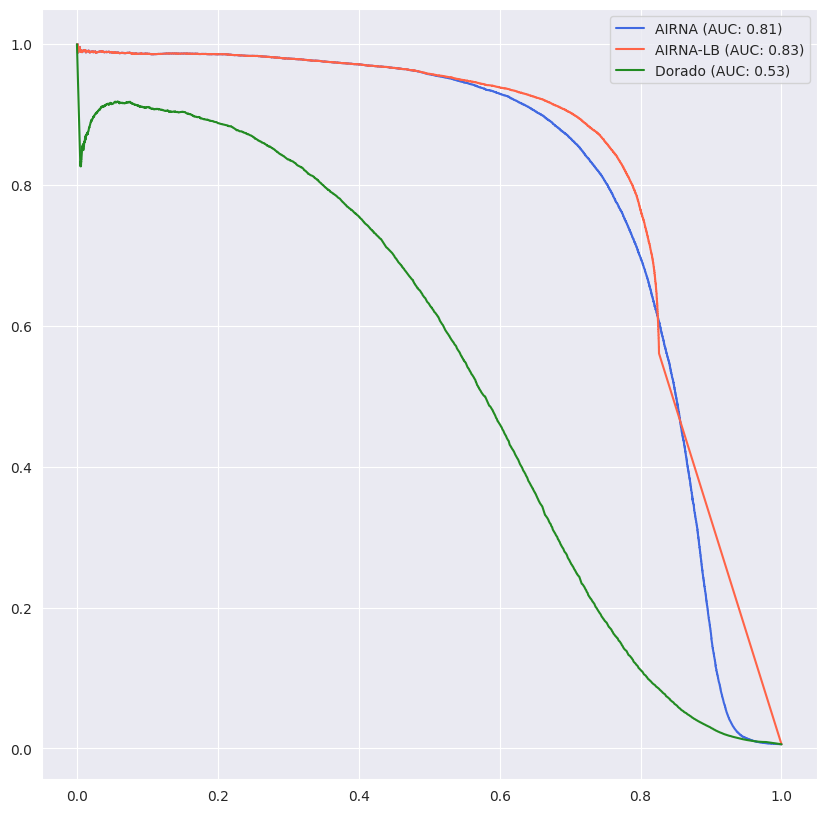

In [89]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(recall, precision, color="royalblue", label=f"AIRNA (AUC: {auc(recall, precision):.2f})")
ax.plot(recall_selected, precision_selected, color="tomato", label=f"AIRNA-LB (AUC: {auc(recall_selected, precision_selected):.2f})")
ax.plot(recall_dorado, precision_dorado, color="forestgreen", label=f"Dorado (AUC: {auc(recall_dorado, precision_dorado):.2f})")
ax.legend()
plt.show()


                label_id      pm6a  count_pm6a       dom  count_dom  \
0         NM_000016:1000  0.000661       257.0  0.000000        258   
1         NM_000016:1008  0.000804       253.0  0.000000        255   
2         NM_000016:1009  0.002531       257.0  0.000000        258   
3         NM_000016:1010  0.003011       253.0  0.011628        258   
4         NM_000016:1014  0.003508       247.0  0.003968        252   
...                  ...       ...         ...       ...        ...   
10257993  NR_182669:3964  0.006612        49.0  0.000000         52   
10257994  NR_182669:3965  0.005538        51.0  0.000000         51   
10257995  NR_182669:3966  0.006250        43.0  0.021739         46   
10257996  NR_182669:3968  0.100220        44.0  0.063830         47   
10257997  NR_182669:3969  0.005694        38.0  0.024390         41   

          mean_pred  depth  label  dom_label   5mer  drach  threshold  
0          0.001252    268      0        0.0  AAACT   True  -1.176040  
1  

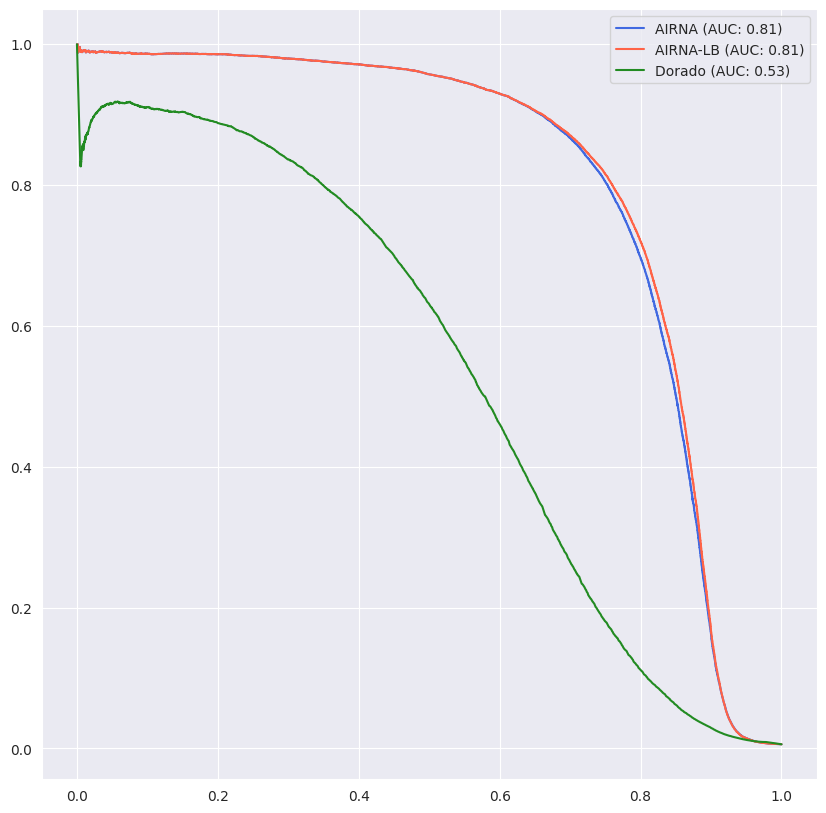

In [91]:
from sklearn.metrics import precision_recall_curve, auc


cell_label_df["threshold"] = 1-(0.02 ** (cell_label_df["mean_pred"] - 0.2))
selected_df = cell_label_df[cell_label_df["pm6a"] > cell_label_df["threshold"]]

print(cell_label_df)
print(selected_df)

original_df_pr = cell_label_df[cell_label_df["label"] >= 0][["label_id", "pm6a"]]
selected_df_pr = selected_df[selected_df["label"] >= 0][["label_id", "pm6a"]]
dorado_df_pr = dorado_label_df[dorado_label_df["label"] >= 0][["label_id", "pred_dorado"]]
selected_df_pr.rename(columns = {"pm6a": "pm6a_lb"}, inplace = True)
print(original_df_pr)
print(selected_df_pr)
print(dorado_df_pr)

data_df = original_df_pr.merge(selected_df_pr, on="label_id", how="outer")
data_df = data_df.merge(dorado_df_pr, on="label_id", how="inner")
data_df = data_df.merge(label_df_filtered[["label_id", "label"]], on="label_id", how="inner")
data_df = data_df.fillna(0)

precision, recall, _ = precision_recall_curve(data_df["label"], data_df["pm6a"])
precision_selected, recall_selected, _ = precision_recall_curve(data_df["label"], data_df["pm6a_lb"])
precision_dorado, recall_dorado, _ = precision_recall_curve(data_df["label"], data_df["pred_dorado"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(recall, precision, color="royalblue", label=f"AIRNA (AUC: {auc(recall, precision):.2f})")
ax.plot(recall_selected, precision_selected, color="tomato", label=f"AIRNA-LB (AUC: {auc(recall_selected, precision_selected):.2f})")
ax.plot(recall_dorado, precision_dorado, color="forestgreen", label=f"Dorado (AUC: {auc(recall_dorado, precision_dorado):.2f})")
ax.legend()
plt.show()
plt.close()


                label_id      pm6a  count_pm6a       dom  count_dom  \
0         NM_000016:1000  0.000661       257.0  0.000000        258   
1         NM_000016:1008  0.000804       253.0  0.000000        255   
2         NM_000016:1009  0.002531       257.0  0.000000        258   
3         NM_000016:1010  0.003011       253.0  0.011628        258   
4         NM_000016:1014  0.003508       247.0  0.003968        252   
...                  ...       ...         ...       ...        ...   
10257993  NR_182669:3964  0.006612        49.0  0.000000         52   
10257994  NR_182669:3965  0.005538        51.0  0.000000         51   
10257995  NR_182669:3966  0.006250        43.0  0.021739         46   
10257996  NR_182669:3968  0.100220        44.0  0.063830         47   
10257997  NR_182669:3969  0.005694        38.0  0.024390         41   

          mean_pred  depth  label  dom_label   5mer  drach  threshold  \
0          0.001252    268      0        0.0  AAACT   True   0.104279   
1

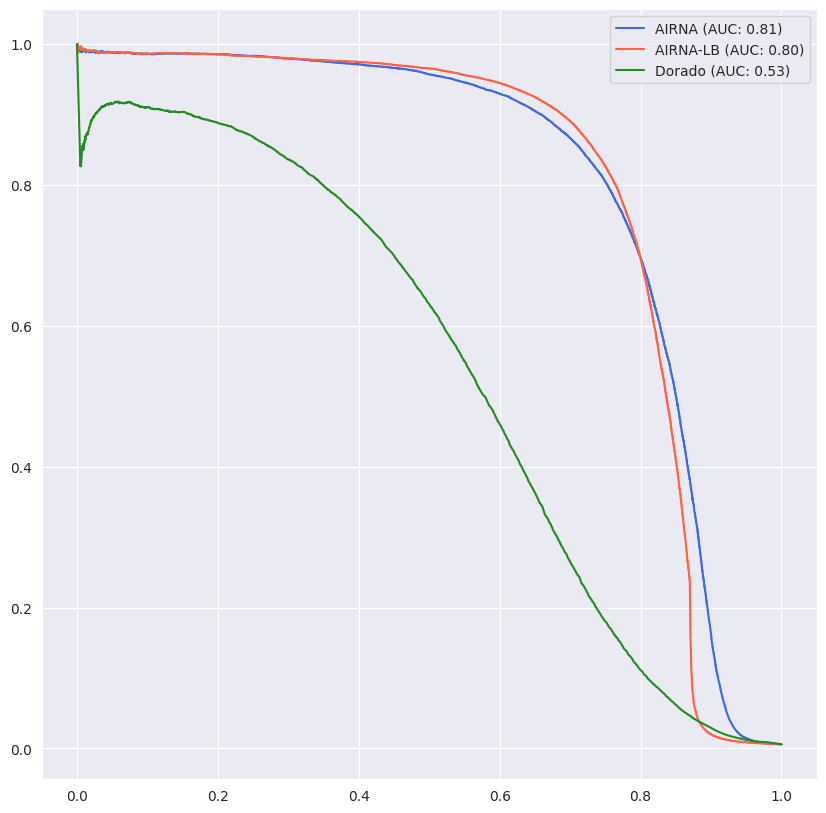

In [103]:

cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["mean_pred"])) * (0.02 ** (cell_label_df["mean_pred"])))
cell_label_df["adj_pm6a"] = np.log10((1-cell_label_df["threshold"]) / (1-cell_label_df["pm6a"]))

 
print(cell_label_df) 

original_df_pr = cell_label_df[cell_label_df["label"] >= 0][["label_id", "pm6a", "adj_pm6a", "label", "dom_label"]] 
dorado_df_pr = dorado_label_df[dorado_label_df["label"] >= 0][["label_id", "pred_dorado"]] 
print(original_df_pr) 
print(dorado_df_pr)
 
data_df = original_df_pr.merge(dorado_df_pr, on="label_id", how="inner") 
data_df = data_df.fillna(0)

precision, recall, _ = precision_recall_curve(data_df["label"], data_df["pm6a"])
precision_selected, recall_selected, _ = precision_recall_curve(data_df["label"], data_df["adj_pm6a"])
precision_dorado, recall_dorado, _ = precision_recall_curve(data_df["label"], data_df["pred_dorado"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(recall, precision, color="royalblue", label=f"AIRNA (AUC: {auc(recall, precision):.2f})")
ax.plot(recall_selected, precision_selected, color="tomato", label=f"AIRNA-LB (AUC: {auc(recall_selected, precision_selected):.2f})")
ax.plot(recall_dorado, precision_dorado, color="forestgreen", label=f"Dorado (AUC: {auc(recall_dorado, precision_dorado):.2f})")
ax.legend()
plt.show()
plt.close()

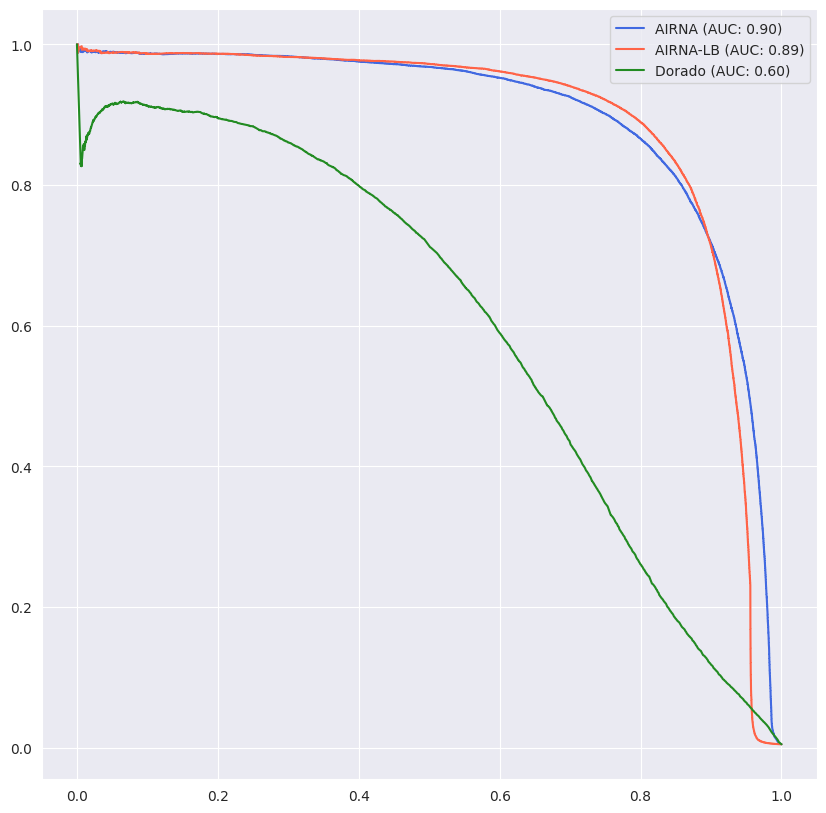

In [106]:

data_df_filtered = data_df[(data_df["dom_label"] > 0.1) | (data_df["label"] == 0)]
 
precision, recall, _ = precision_recall_curve(data_df_filtered["label"], data_df_filtered["pm6a"])
precision_selected, recall_selected, _ = precision_recall_curve(data_df_filtered["label"], data_df_filtered["adj_pm6a"])
precision_dorado, recall_dorado, _ = precision_recall_curve(data_df_filtered["label"], data_df_filtered["pred_dorado"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(recall, precision, color="royalblue", label=f"AIRNA (AUC: {auc(recall, precision):.2f})")
ax.plot(recall_selected, precision_selected, color="tomato", label=f"AIRNA-LB (AUC: {auc(recall_selected, precision_selected):.2f})")
ax.plot(recall_dorado, precision_dorado, color="forestgreen", label=f"Dorado (AUC: {auc(recall_dorado, precision_dorado):.2f})")
ax.legend()
plt.show()
plt.close()


                label_id      pm6a  count_pm6a       dom  count_dom  \
0         NM_000016:1000  0.000661       257.0  0.000000        258   
1         NM_000016:1008  0.000804       253.0  0.000000        255   
2         NM_000016:1009  0.002531       257.0  0.000000        258   
3         NM_000016:1010  0.003011       253.0  0.011628        258   
4         NM_000016:1014  0.003508       247.0  0.003968        252   
...                  ...       ...         ...       ...        ...   
10257993  NR_182669:3964  0.006612        49.0  0.000000         52   
10257994  NR_182669:3965  0.005538        51.0  0.000000         51   
10257995  NR_182669:3966  0.006250        43.0  0.021739         46   
10257996  NR_182669:3968  0.100220        44.0  0.063830         47   
10257997  NR_182669:3969  0.005694        38.0  0.024390         41   

          mean_pred  depth  label  dom_label   5mer  drach  threshold  \
0          0.001252    268      0        0.0  AAACT   True   0.104279   
1

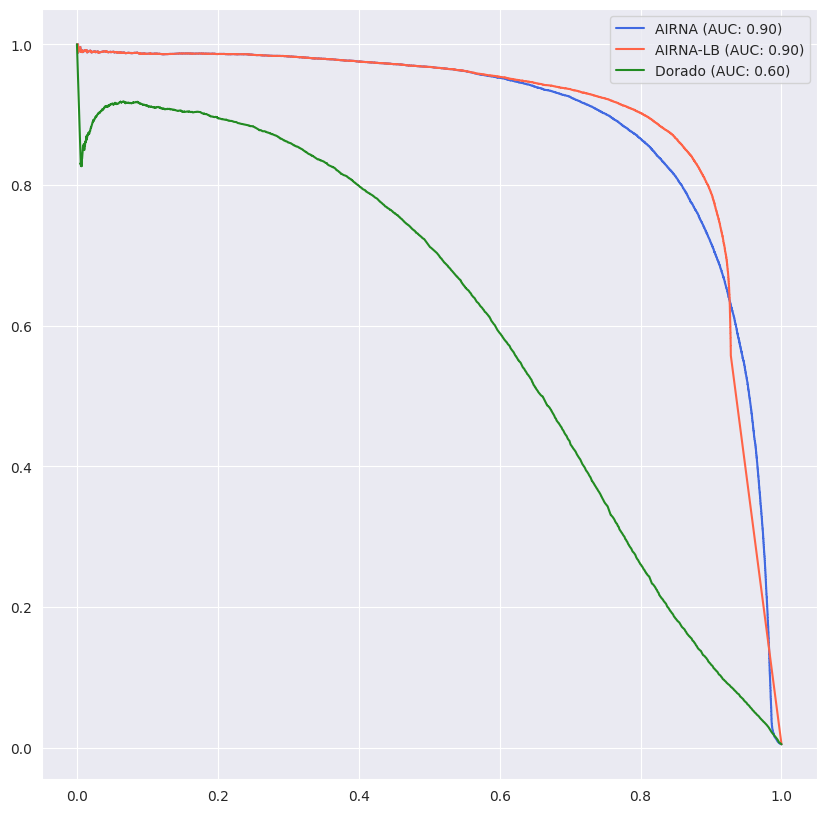

In [107]:

cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["mean_pred"])) * (0.02 ** (cell_label_df["mean_pred"])))
selected_df = cell_label_df[cell_label_df["pm6a"] > cell_label_df["threshold"]]

print(cell_label_df)
print(selected_df)

original_df_pr = cell_label_df[cell_label_df["label"] >= 0][["label_id", "pm6a"]]
selected_df_pr = selected_df[selected_df["label"] >= 0][["label_id", "pm6a"]]
dorado_df_pr = dorado_label_df[dorado_label_df["label"] >= 0][["label_id", "pred_dorado"]]
selected_df_pr.rename(columns = {"pm6a": "pm6a_lb"}, inplace = True)
print(original_df_pr)
print(selected_df_pr)
print(dorado_df_pr)

data_df = original_df_pr.merge(selected_df_pr, on="label_id", how="outer")
data_df = data_df.merge(dorado_df_pr, on="label_id", how="inner")
label_df_filtered_filtered = label_df_filtered[(label_df_filtered["dom_label"] > 0.1) | (label_df_filtered["label"] == 0)]
data_df = data_df.merge(label_df_filtered_filtered[["label_id", "label"]], on="label_id", how="inner")
data_df = data_df.fillna(0)


precision, recall, _ = precision_recall_curve(data_df["label"], data_df["pm6a"])
precision_selected, recall_selected, _ = precision_recall_curve(data_df["label"], data_df["pm6a_lb"])
precision_dorado, recall_dorado, _ = precision_recall_curve(data_df["label"], data_df["pred_dorado"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(recall, precision, color="royalblue", label=f"AIRNA (AUC: {auc(recall, precision):.2f})")
ax.plot(recall_selected, precision_selected, color="tomato", label=f"AIRNA-LB (AUC: {auc(recall_selected, precision_selected):.2f})")
ax.plot(recall_dorado, precision_dorado, color="forestgreen", label=f"Dorado (AUC: {auc(recall_dorado, precision_dorado):.2f})")
ax.legend()
plt.show()
plt.close()
